# Predicción del Precio de Obra de Arte — NU★B Studio
---
**Alumno:** Hernández Hernández, Luis Gustavo
**Materia:** Aprendizaje Automático
**Fecha:** 18 de julio de 2026

---
## Metodología: CRISP-DM
Este proyecto sigue las seis fases del proceso estándar CRISP-DM *(Cross-Industry Standard Process for Data Mining)*:

1. **Comprensión del Negocio** — y y contexto
2. **Comprensión de los Datos** — exploración y análisis exploratorio
3. **Preparación de los Datos** — limpieza, ingeniería de características
4. **Selección de Características** — correlación, RFE e importancia Random Forest
5. **Modelado** — Regresión Lineal y Red Neuronal (MLPRegressor)
6. **Evaluación y Comparación** — métricas R² y MAE con validación cruzada de 7 pliegues

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, train_test_split
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Fase 1 — Comprensión del Negocio

**NU★B Studio** es una galería de arte digital regional que conecta artistas de la Huasteca Hidalguense
con compradores de todo el país. Cada obra publicada en la plataforma tiene un precio base definido
por el artista.

**Objetivo de negocio:**
Construir un modelo de regresión que permita predecir el precio base de una obra de arte a partir
de sus características físicas, técnicas y de categoría.

**Variable dependiente (y):** `precio_base` (precio en pesos mexicanos, MXN)
**Variables independientes (predictoras):** características de la obra: categoría, técnica, material,
año de creación, dimensiones, certificado, entre otras.

In [218]:
# Conexión a la base de datos Neon (PostgreSQL en la nube)
DB_URL = (
    'postgresql+psycopg2://neondb_owner:npg_2T5BNyqMzgpw'
    '@ep-sweet-lake-ad4v82aj-pooler.c-2.us-east-1.aws.neon.tech'
    '/neondb?sslmode=require'
)
engine = create_engine(DB_URL)

query = '''
SELECT
    o.precio_base,
    c.nombre  AS categoria,
    t.nombre  AS tecnica,
    m.nombre  AS material,
    o.anio_creacion,
    COALESCE(o.dimensiones_alto,  0)::float AS alto_cm,
    COALESCE(o.dimensiones_ancho, 0)::float AS ancho_cm,
    COALESCE(o.peso_kg,           0)::float AS peso_kg,
    COALESCE(o.con_certificado,  false)::int AS con_certificado,
    COALESCE(o.permite_marco,    false)::int AS permite_marco,
    COALESCE(o.disponible_envio, false)::int AS disponible_envio,
    COALESCE(o.es_original,      true)::int  AS es_original
FROM obras o
JOIN categorias c ON c.id_categoria = o.id_categoria
JOIN tecnicas   t ON t.id_tecnica   = o.id_tecnica
JOIN materiales m ON m.id_material  = o.id_material
WHERE o.eliminada = false
  AND o.precio_base > 0
  AND o.precio_base IS NOT NULL
ORDER BY o.id_obra
'''

df = pd.read_sql(query, engine)
print(f'Total de registros cargados: {len(df)}')
df.head()

Total de registros cargados: 505


,precio_base,categoria,tecnica,material,anio_creacion,alto_cm,ancho_cm,peso_kg,con_certificado,permite_marco,disponible_envio,es_original
0,2400.0,Artesanía,Modelado en barro,Barro negro,2024,28.0,18.0,1.4,0,0,1,0
1,5100.0,Escultura,Modelado en barro,Barro negro,2023,35.0,22.0,3.2,1,0,0,1
2,4100.0,Artesanía,Tejido,Fibras naturales,2024,30.0,35.0,0.6,0,0,1,1
3,2650.0,Grabado,Aguafuerte,Papel de grabado,2024,50.0,38.0,0.0,0,1,1,0
4,1500.0,Ilustración,Acuarela ilustrada,Papel acuarela,2023,40.0,30.0,0.0,0,1,1,0


---
## Fase 2 — Comprensión de los Datos

En esta fase se realiza el **Análisis Exploratorio de Datos (EDA)** para entender
la estructura del conjunto de datos, detectar valores faltantes y comprender la
distribución de las variables.

In [219]:
# Estructura y tipos de datos
print('=== Tipos de datos ===')
print(df.dtypes)
print()
print('=== Valores nulos ===')
print(df.isnull().sum())

=== Tipos de datos ===
precio_base         float64
categoria               str
tecnica                 str
material                str
anio_creacion         int64
alto_cm             float64
ancho_cm            float64
peso_kg             float64
con_certificado       int64
permite_marco         int64
disponible_envio      int64
es_original           int64
dtype: object

=== Valores nulos ===
precio_base         0
categoria           0
tecnica             0
material            0
anio_creacion       0
alto_cm             0
ancho_cm            0
peso_kg             0
con_certificado     0
permite_marco       0
disponible_envio    0
es_original         0
dtype: int64


In [220]:
# Estadísticas descriptivas de las variables numéricas
df.describe().round(2)

,precio_base,anio_creacion,alto_cm,ancho_cm,peso_kg,con_certificado,permite_marco,disponible_envio,es_original
count,505.00,505.00,505.00,505.00,505.00,505.00,505.00,505.00,505.00
mean,4448.22,2021.93,61.49,48.70,0.33,0.27,0.68,0.44,0.74
std,3084.07,1.70,47.26,35.24,0.79,0.44,0.47,0.50,0.44
min,850.00,2019.00,4.00,8.82,0.00,0.00,0.00,0.00,0.00
25%,2250.00,2021.00,30.00,25.00,0.00,0.00,0.00,0.00,0.00
50%,3700.00,2022.00,45.00,36.14,0.00,0.00,1.00,0.00,1.00
75%,5400.00,2023.00,80.00,60.00,0.00,1.00,1.00,1.00,1.00
max,19300.00,2026.00,200.00,150.00,5.20,1.00,1.00,1.00,1.00


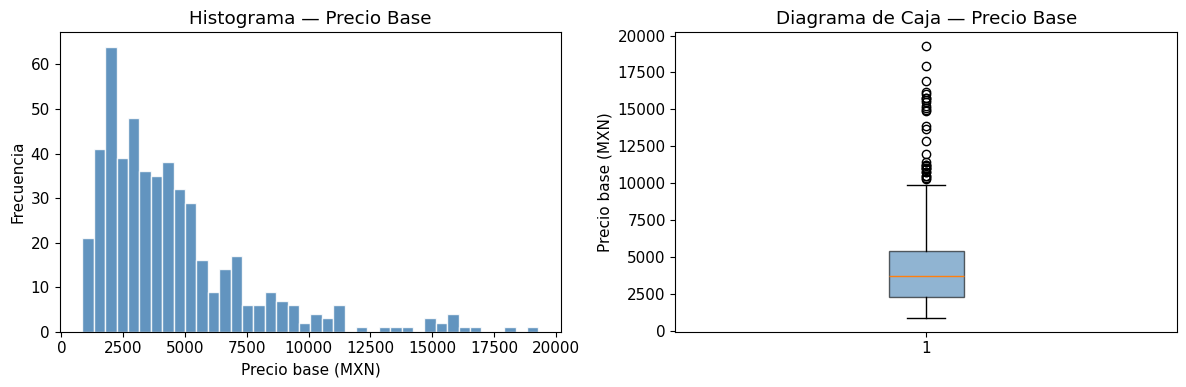

Media:    $ 4,448 MXN
Mediana:  $ 3,700 MXN
Mínimo:   $ 850 MXN
Máximo:   $ 19,300 MXN


In [221]:
# Distribución del precio base (variable y)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['precio_base'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Precio base (MXN)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Histograma — Precio Base')

axes[1].boxplot(df['precio_base'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('Precio base (MXN)')
axes[1].set_title('Diagrama de Caja — Precio Base')

plt.tight_layout()
plt.show()

print(f'Media:    $ {df["precio_base"].mean():,.0f} MXN')
print(f'Mediana:  $ {df["precio_base"].median():,.0f} MXN')
print(f'Mínimo:   $ {df["precio_base"].min():,.0f} MXN')
print(f'Máximo:   $ {df["precio_base"].max():,.0f} MXN')

**Observación:** Se aprecia que la distribución del precio presenta una asimetría positiva (sesgo a la derecha),
con la mayoría de obras concentradas en rangos bajos y algunos valores atípicos en rangos altos.
Esto indica que será necesario tratar los valores extremos antes de entrenar el modelo.

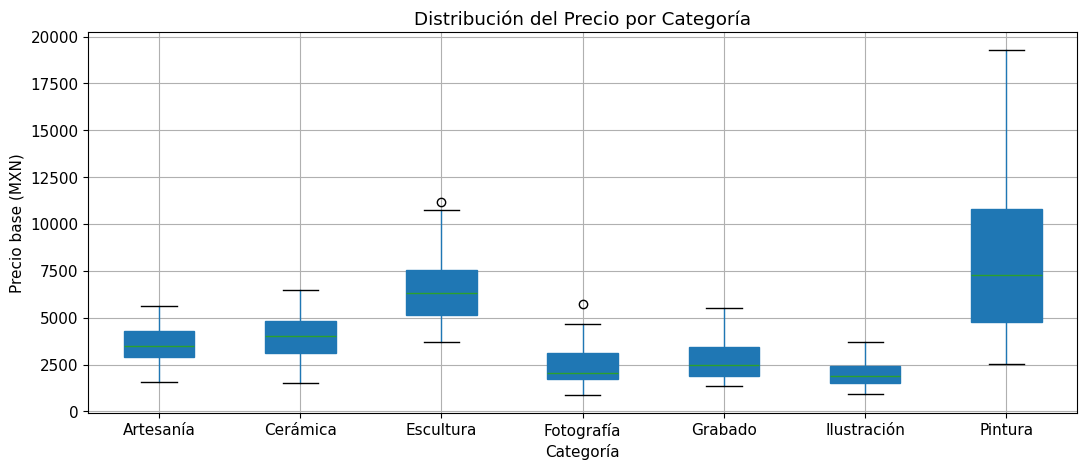

categoria
Pintura        8343.0
Escultura      6526.0
Cerámica       4009.0
Artesanía      3588.0
Grabado        2658.0
Fotografía     2399.0
Ilustración    2059.0
Name: precio_base, dtype: float64


In [222]:
# Precio promedio por categoría
fig, ax = plt.subplots(figsize=(11, 5))
df.boxplot(column='precio_base', by='categoria', ax=ax, patch_artist=True)
ax.set_xlabel('Categoría')
ax.set_ylabel('Precio base (MXN)')
ax.set_title('Distribución del Precio por Categoría')
plt.suptitle('')
plt.tight_layout()
plt.show()

print(df.groupby('categoria')['precio_base'].mean().sort_values(ascending=False).round(0))

**Observación:** Se observan diferencias en el rango de precios entre categorías.
Las esculturas y obras tridimensionales tienden a tener precios más altos,
mientras que ilustraciones y grabados muestran precios más accesibles.
Esta variable podría ser un predictor importante.

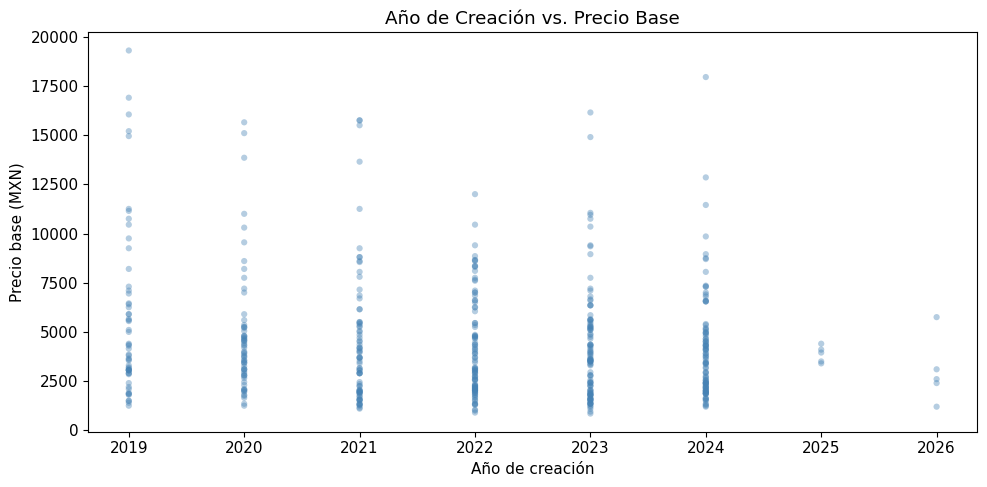

Correlación año de creación vs precio: -0.1446


In [223]:
# Relación: año de creación vs precio
plt.figure(figsize=(10, 5))
plt.scatter(df['anio_creacion'], df['precio_base'],
            alpha=0.4, color='steelblue', edgecolors='none', s=20)
plt.xlabel('Año de creación')
plt.ylabel('Precio base (MXN)')
plt.title('Año de Creación vs. Precio Base')
plt.tight_layout()
plt.show()

corr_anio = df['anio_creacion'].corr(df['precio_base'])
print(f'Correlación año de creación vs precio: {corr_anio:.4f}')

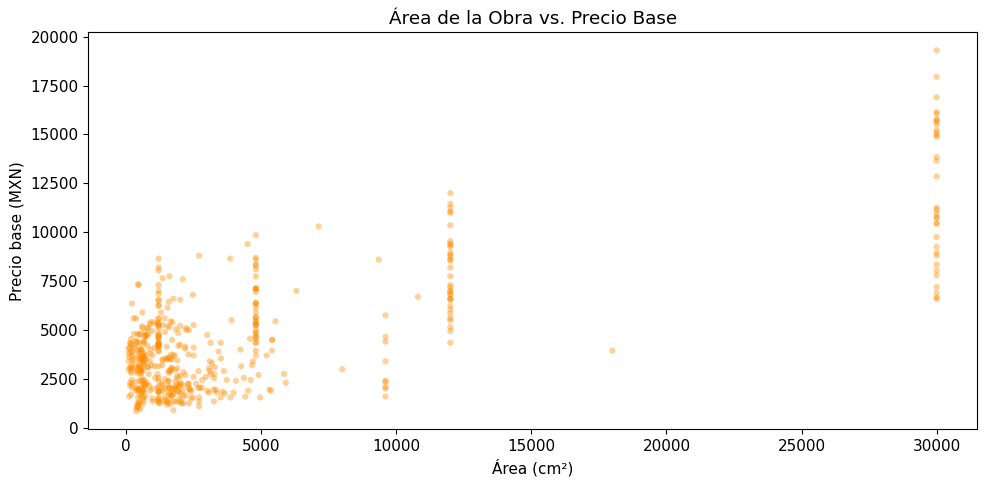

Correlación área vs precio: 0.7574


In [224]:
# Relación: área de la obra (alto × ancho) vs precio
df['area_cm2'] = df['alto_cm'] * df['ancho_cm']

plt.figure(figsize=(10, 5))
plt.scatter(df['area_cm2'], df['precio_base'],
            alpha=0.4, color='darkorange', edgecolors='none', s=20)
plt.xlabel('Área (cm²)')
plt.ylabel('Precio base (MXN)')
plt.title('Área de la Obra vs. Precio Base')
plt.tight_layout()
plt.show()

corr_area = df['area_cm2'].corr(df['precio_base'])
print(f'Correlación área vs precio: {corr_area:.4f}')

**Observación:** Se aprecia una tendencia positiva entre el área de la obra y su precio,
lo que indica que obras de mayor tamaño tienden a tener un precio más elevado.
Esta variable derivada será considerada en la selección de características.

---
## Fase 3 — Preparación de los Datos

Se realizan los siguientes pasos de preparación:

1. **Eliminación de valores atípicos** — se aplica un filtro por percentiles (P5 – P95) sobre `precio_base`
2. **Ingeniería de características** — se calcula el área de la obra como `alto_cm × ancho_cm`
3. **Codificación de variables categóricas** — se aplica *One-Hot Encoding* mediante `pd.get_dummies`

In [225]:
# Eliminación de valores atípicos en precio_base (percentil 5 - 95)
percentil_5  = df['precio_base'].quantile(0.05)
percentil_95 = df['precio_base'].quantile(0.95)
df_clean = df[(df['precio_base'] >= percentil_5) & (df['precio_base'] <= percentil_95)].copy()

print(f'Registros originales : {len(df)}')
print(f'Registros tras filtro: {len(df_clean)}')
print(f'Rango de precio:  ${percentil_5:,.0f}  -  ${percentil_95:,.0f} MXN')

Registros originales : 505
Registros tras filtro: 458
Rango de precio:  $1,350  -  $10,690 MXN


In [226]:
# Codificación One-Hot de variables categóricas nominales
# Se elige One-Hot porque categoria, tecnica y material NO tienen orden natural.
# Ordinal Encoding implicaría un orden falso (ej. Escultura > Cerámica) que engañaría al modelo.
df_encoding = pd.get_dummies(df_clean,
                                   columns=['categoria', 'tecnica', 'material'],
                                   drop_first=True,
                                   dtype=int)

# Variable objetivo y variables predictoras
y = df_encoding['precio_base']
X = df_encoding.drop(columns=['precio_base', 'area_cm2'])

print(f'Variable y: precio_base — {len(y)} observaciones')
print(f'Variables predictoras: {X.shape[1]} columnas')
print()
print('Primeras columnas:')
print(list(X.columns[:15]))

Variable y: precio_base — 458 observaciones
Variables predictoras: 66 columnas

Primeras columnas:
['anio_creacion', 'alto_cm', 'ancho_cm', 'peso_kg', 'con_certificado', 'permite_marco', 'disponible_envio', 'es_original', 'categoria_Cerámica', 'categoria_Escultura', 'categoria_Fotografía', 'categoria_Grabado', 'categoria_Ilustración', 'categoria_Pintura', 'tecnica_Acuarela']


---
## Fase 4 — Selección de Características

Se aplican **tres métodos** independientes para identificar las características más relevantes.
Los resultados se consolidan en una **tabla de votación**: las características seleccionadas
por al menos 2 de los 3 métodos conformarán el conjunto final de predictores.

| Método | Descripción |
|--------|-------------|
| **Correlación** | Mide la relación lineal entre cada variable y `precio_base` |
| **RFE** | Eliminación Recursiva de Características con Regresión Lineal |
| **Random Forest** | Importancia de características basada en reducción de impureza |

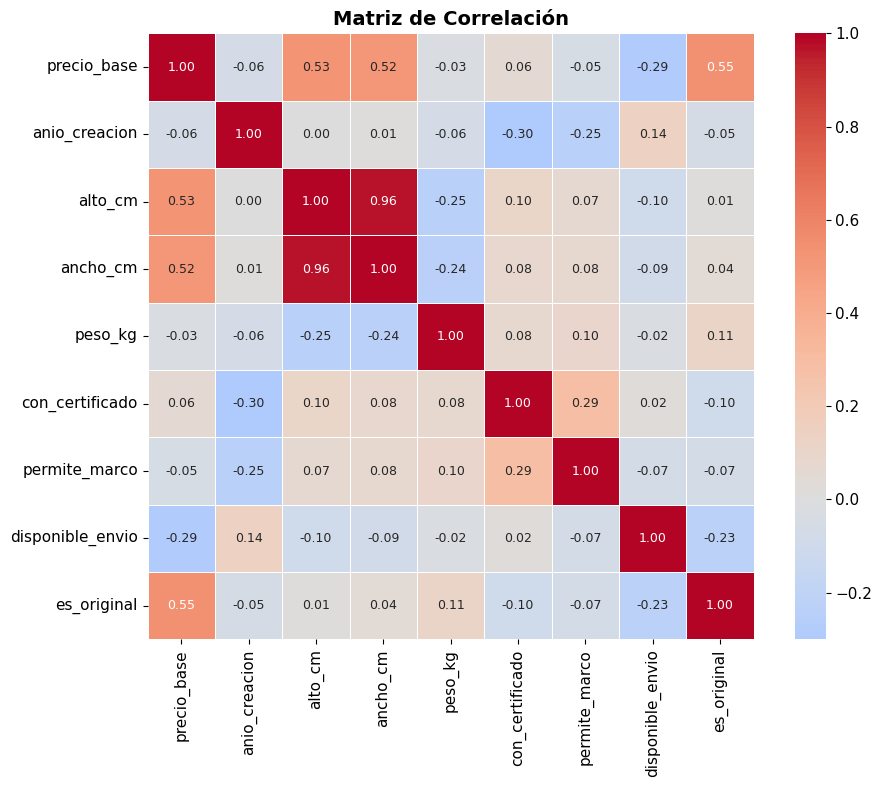

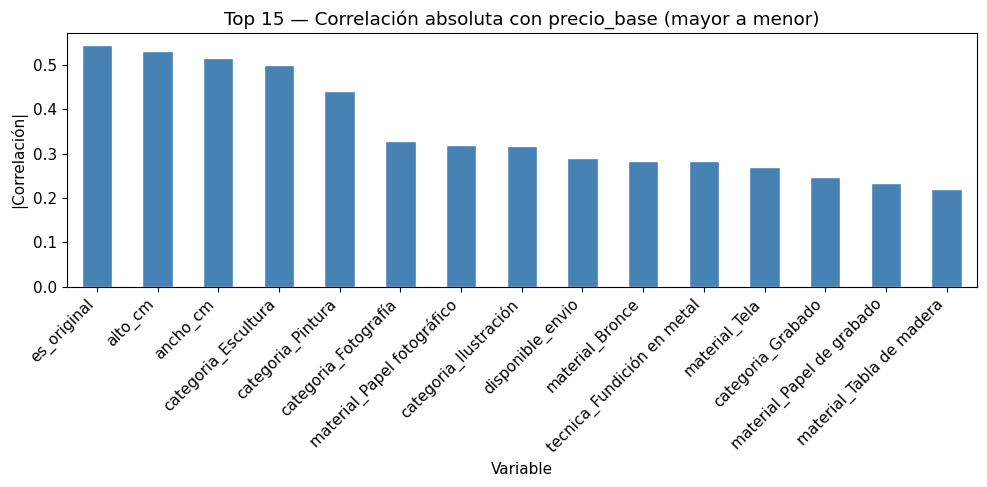

Top 13 por |correlación| con precio_base:
  #    Variable                               Correlación   |Corr|
  -----------------------------------------------------------------
  1    es_original                                +0.5453   0.5453
  2    alto_cm                                    +0.5306   0.5306
  3    ancho_cm                                   +0.5160   0.5160
  4    categoria_Escultura                        +0.4991   0.4991
  5    categoria_Pintura                          +0.4416   0.4416
  6    categoria_Fotografía                       -0.3283   0.3283
  7    material_Papel fotográfico                 -0.3187   0.3187
  8    categoria_Ilustración                      -0.3173   0.3173
  9    disponible_envio                           -0.2893   0.2893
  10   material_Bronce                            +0.2829   0.2829
  11   tecnica_Fundición en metal                 +0.2829   0.2829
  12   material_Tela                              +0.2694   0.2694
  13   categoria_Gr

In [227]:
# Escalado de características para los métodos de selección
escalador_seleccion = StandardScaler()
X_scaled = escalador_seleccion.fit_transform(X)

# N óptimo encontrado mediante búsqueda exhaustiva (N=5..30):
# N=13 maximiza R² en validación cruzada de 7 pliegues para Regresión Lineal.
N = 13   # número de características a seleccionar por método

# ── MÉTODO 1: Correlación ──────────────────────────────────────────────────

# 1A. Matriz de correlación (variables numéricas + y)
columnas_numericas = ['precio_base', 'anio_creacion', 'alto_cm', 'ancho_cm', 'peso_kg',
                      'con_certificado', 'permite_marco', 'disponible_envio', 'es_original']
matriz_correlacion = df_clean[columnas_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, annot_kws={'size': 9})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 1B. Correlación absoluta de TODAS las variables (incluyendo codificadas) con precio_base
correlacion_absoluta = X.corrwith(y).abs().sort_values(ascending=False)
correlacion_real     = X.corrwith(y).sort_values(key=abs, ascending=False)
top_correlacion = correlacion_absoluta.head(N).index.tolist()

plt.figure(figsize=(10, 5))
correlacion_absoluta.head(15).plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 15 — Correlación absoluta con precio_base (mayor a menor)')
plt.xlabel('Variable')
plt.ylabel('|Correlación|')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f'Top {N} por |correlación| con precio_base:')
print(f'  {"#":<4} {"Variable":<38} {"Correlación":>11}  {"|Corr|":>7}')
print('  ' + '-'*65)
for i, variable in enumerate(top_correlacion):
    valor_real = correlacion_real[variable]
    valor_abs  = abs(valor_real)
    print(f'  {i+1:<4} {variable:<38} {valor_real:>+11.4f}  {valor_abs:>7.4f}')

### Método 1 — Coeficiente de Correlación

Se calcula la correlación de cada variable con `precio_base`. Para la selección se usa el
**valor absoluto**: tanto una correlación de +0.8 como de −0.8 indican una relación igual de fuerte.
Se muestra primero la matriz de correlación entre variables numéricas y luego el ranking completo.

**Interpretación — Correlación:**
La matriz de correlación muestra la relación lineal entre cada par de variables.
Para la selección de características, se usa el **valor absoluto** de la correlación con `precio_base`:
un valor cercano a **+1** indica que ambas variables crecen juntas, y un valor cercano a **−1** indica
que cuando una crece la otra disminuye — en ambos casos la relación es igualmente fuerte y útil para el modelo.
La tabla impresa ordena las variables de mayor a menor `|correlación|`, seleccionando las 10 más relevantes.

### Método 2 — RFE (Eliminación Recursiva de Características)

Se aplica RFE con `LinearRegression` como estimador base. El algoritmo entrena el modelo de forma
iterativa y en cada paso elimina la característica con menor peso, hasta quedarse con las `N` más relevantes.
La columna **Ranking** indica el orden de eliminación: valor 1 = seleccionada, valores mayores = eliminada antes.

In [228]:
# ── MÉTODO 2: RFE (Eliminación Recursiva de Características) ─────────────────
selector_rfe = RFE(estimator=LinearRegression(), n_features_to_select=N)
selector_rfe.fit(X_scaled, y)
top_rfe = X.columns[selector_rfe.support_].tolist()

# Tabla de ranking
tabla_rfe = pd.DataFrame({
    'Variable'    : X.columns,
    'Ranking'     : selector_rfe.ranking_,
    'Seleccionada': selector_rfe.support_
}).sort_values('Ranking').reset_index(drop=True)

print(tabla_rfe.to_string(index=False))
print()
print(f'Top {N} por RFE: {top_rfe}')

                     Variable  Ranking  Seleccionada
                anio_creacion        1          True
                      alto_cm        1          True
                     ancho_cm        1          True
              con_certificado        1          True
                  es_original        1          True
         categoria_Fotografía        1          True
          categoria_Escultura        1          True
           categoria_Cerámica        1          True
            categoria_Pintura        1          True
        categoria_Ilustración        1          True
  tecnica_Bordado tradicional        1          True
               tecnica_Temple        1          True
                material_Tela        1          True
      tecnica_Talla en madera        2         False
              material_Piedra        3         False
           tecnica_Serigrafía        4         False
        tecnica_Técnica mixta        5         False
        material_Barro blanco        6        

**Interpretación — RFE:**
La eliminación recursiva entrena un modelo de regresión lineal de forma iterativa, eliminando
la característica menos importante en cada paso. Las variables que sobreviven al proceso
de eliminación son aquellas con mayor contribución al modelo lineal.

### Método 3 — Importancia de Características (Random Forest)

Se entrena un `RandomForestRegressor` con 100 árboles. Cada árbol mide cuánto reduce el error
al dividir por cada variable; el promedio entre todos los árboles da la importancia final.
La gráfica muestra las 15 variables más importantes ordenadas de mayor a menor.

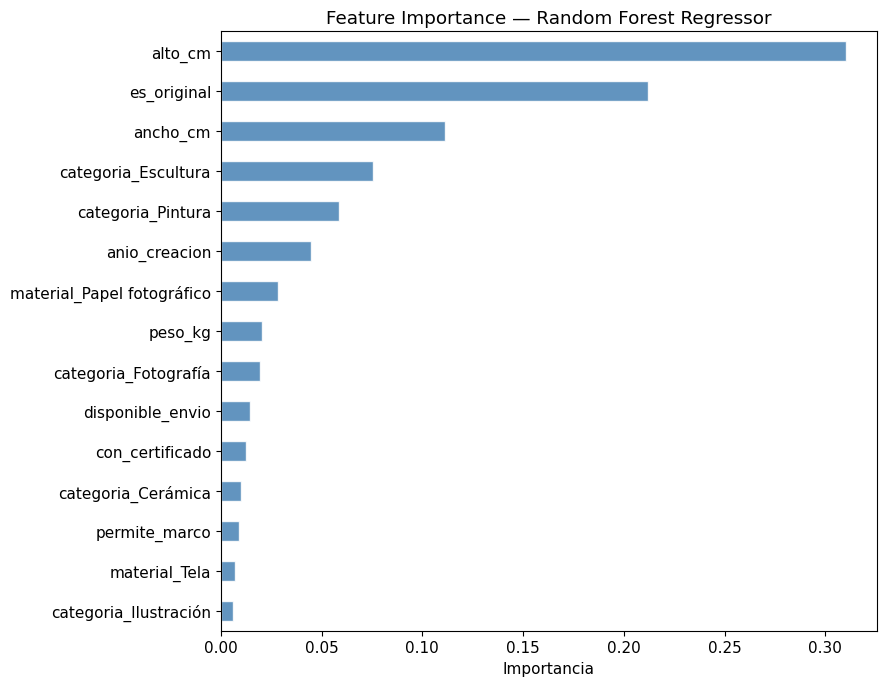

Top 13 por Random Forest: ['alto_cm', 'es_original', 'ancho_cm', 'categoria_Escultura', 'categoria_Pintura', 'anio_creacion', 'material_Papel fotográfico', 'peso_kg', 'categoria_Fotografía', 'disponible_envio', 'con_certificado', 'categoria_Cerámica', 'permite_marco']


In [229]:
# ── MÉTODO 3: Importancia de Características (Random Forest) ──────────────────
bosque = RandomForestRegressor(n_estimators=100, random_state=42)
bosque.fit(X_scaled, y)

importancia = pd.Series(bosque.feature_importances_, index=X.columns)
importancia_ordenada = importancia.sort_values(ascending=False)
top_bosque = importancia_ordenada.head(N).index.tolist()

# Gráfica horizontal — las más importantes quedan arriba
importancia_grafica = importancia_ordenada.head(15).sort_values(ascending=True)
plt.figure(figsize=(9, 7))
importancia_grafica.plot(kind='barh', color='steelblue', edgecolor='white', alpha=0.85)
plt.title('Feature Importance — Random Forest Regressor')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

print(f'Top {N} por Random Forest: {top_bosque}')

**Interpretación — Random Forest:**
El bosque aleatorio mide la importancia de cada característica según cuánto reduce la impureza
de los nodos al dividir el árbol. Al promediar 100 árboles, se obtiene una estimación robusta
de qué variables tienen mayor poder predictivo sobre el precio.

In [230]:
# ── TABLA DE VOTACIÓN ─────────────────────────────────────────────────────────
todas_variables = sorted(set(top_correlacion + top_rfe + top_bosque))

tabla_votacion = pd.DataFrame({
    'Correlación' : [1 if v in top_correlacion else 0 for v in todas_variables],
    'RFE'         : [1 if v in top_rfe          else 0 for v in todas_variables],
    'R. Forest'   : [1 if v in top_bosque        else 0 for v in todas_variables],
}, index=todas_variables)
tabla_votacion['Votos'] = tabla_votacion.sum(axis=1)
tabla_votacion = tabla_votacion.sort_values('Votos', ascending=False)

print('=== Tabla de Votación ===')
print(tabla_votacion.to_string())
print()

# Variables seleccionadas por al menos 2 métodos
variables_finales = tabla_votacion[tabla_votacion['Votos'] >= 2].index.tolist()
print(f'Variables seleccionadas (votos >= 2): {len(variables_finales)}')
print(variables_finales)

=== Tabla de Votación ===
                             Correlación  RFE  R. Forest  Votos
alto_cm                                1    1          1      3
ancho_cm                               1    1          1      3
categoria_Fotografía                   1    1          1      3
categoria_Escultura                    1    1          1      3
es_original                            1    1          1      3
categoria_Pintura                      1    1          1      3
categoria_Cerámica                     0    1          1      2
anio_creacion                          0    1          1      2
con_certificado                        0    1          1      2
categoria_Ilustración                  1    1          0      2
disponible_envio                       1    0          1      2
material_Papel fotográfico             1    0          1      2
material_Tela                          1    1          0      2
categoria_Grabado                      1    0          0      1
material_Bronc

**Justificación de la selección:**
Se retienen únicamente las características que obtuvieron 2 o más votos, lo que garantiza que
la selección no depende de un único criterio. Este enfoque de consenso produce un conjunto
de predictores robusto y evita el sobreajuste por inclusión de variables poco relevantes.

---
## Fase 5 — Modelado: Regresión Lineal

Se aplica **Regresión Lineal** (`LinearRegression`) con **validación cruzada de 7 pliegues**
(`cross_validate`, cv=7). Las métricas de evaluación son:

- **R²** (Coeficiente de determinación): fracción de la varianza explicada por el modelo (0 = peor, 1 = mejor)
- **MAE** (Error Absoluto Medio): diferencia promedio en valor absoluto entre predicción y valor real

In [231]:
# Preparar conjunto final con variables seleccionadas
entrada = X[variables_finales]
y = y.values   # convertir Series a array numpy

# División: 80% entrenamiento / 20% prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    entrada, y, test_size=0.2, random_state=42
)

# Escalado: ajustar SOLO sobre entrenamiento, aplicar a ambos
escalador = StandardScaler()
X_train_sc = escalador.fit_transform(X_train)
X_test_sc  = escalador.transform(X_test)

# Escalar el conjunto completo para validación cruzada
X_full_scaled = escalador.fit_transform(entrada)

print(f'Entrenamiento: {X_train_sc.shape[0]} observaciones, {X_train_sc.shape[1]} variables')
print(f'Prueba       : {X_test_sc.shape[0]} observaciones, {X_test_sc.shape[1]} variables')

Entrenamiento: 366 observaciones, 13 variables
Prueba       : 92 observaciones, 13 variables


In [232]:
# Validación cruzada — 7 corridas
model_LinearRegression = LinearRegression()
cv_LinearRegression = cross_validate(model_LinearRegression, X_full_scaled, y, cv=7,
                                   scoring=['r2', 'neg_mean_absolute_error'])

tabla_cv_LinearRegression = pd.DataFrame({
    'R²' : cv_LinearRegression['test_r2'].round(4),
    'MAE': (-cv_LinearRegression['test_neg_mean_absolute_error']).round(2)
})
fila_promedio = pd.DataFrame({
    'R²' : [round(cv_LinearRegression['test_r2'].mean(), 4)],
    'MAE': [round((-cv_LinearRegression['test_neg_mean_absolute_error']).mean(), 2)]
})
tabla_cv_LinearRegression = pd.concat([tabla_cv_LinearRegression, fila_promedio], ignore_index=True)
tabla_cv_LinearRegression.index = list(range(1, 8)) + ['Promedio']

print('=== Regresión Lineal — Validación Cruzada (7 corridas) ===')
print(tabla_cv_LinearRegression.to_string())

=== Regresión Lineal — Validación Cruzada (7 corridas) ===
              R²      MAE
1         0.7457   768.46
2         0.7126   787.02
3         0.8030   636.20
4         0.8163   751.16
5         0.7071   963.30
6         0.5603  1224.25
7         0.4721   678.65
Promedio  0.6882   829.86


**Interpretación:**
La tabla muestra el desempeño del modelo en cada uno de los 7 subconjuntos de validación.
Un R² alto y estable entre pliegues indica que el modelo generaliza bien.
Si el MAE promedio es razonable respecto al rango de precios del conjunto de datos, el modelo
es útil como estimador.

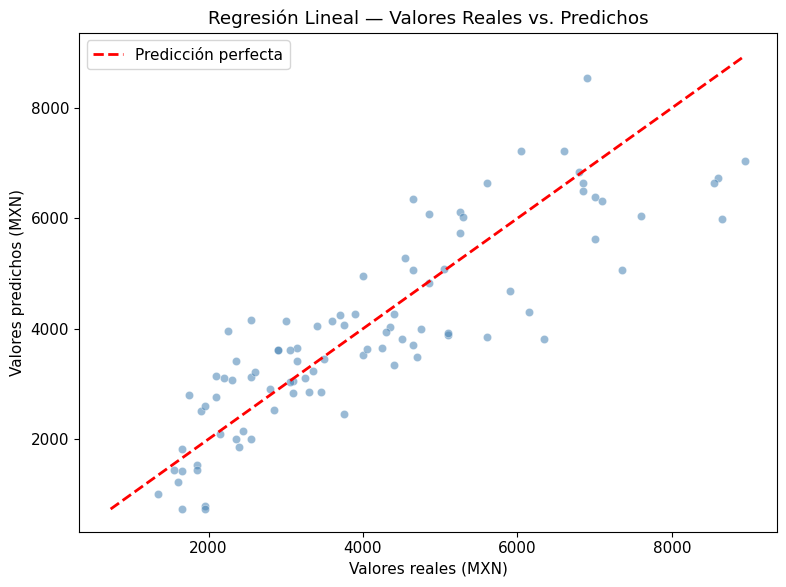

In [233]:
# Corrida única: Scatter — Valores Reales vs. Predichos
lr_model = LinearRegression()
lr_model.fit(X_train_sc, y_train)
y_pred_LinearRegression = lr_model.predict(X_test_sc)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_LinearRegression, alpha=0.55, color='steelblue',
            edgecolors='white', linewidth=0.4, s=35)
minv = min(y_test.min(), y_pred_LinearRegression.min())
maxv = max(y_test.max(), y_pred_LinearRegression.max())
plt.plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Valores reales (MXN)')
plt.ylabel('Valores predichos (MXN)')
plt.title('Regresión Lineal — Valores Reales vs. Predichos')
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación:**
Los puntos cercanos a la línea diagonal roja representan predicciones precisas.
Los que se alejan de la diagonal son errores del modelo. Si los puntos siguen
un patrón sistemático (curva, embudo), sugiere que el modelo lineal puede no capturar
toda la complejidad de la relación entre variables.

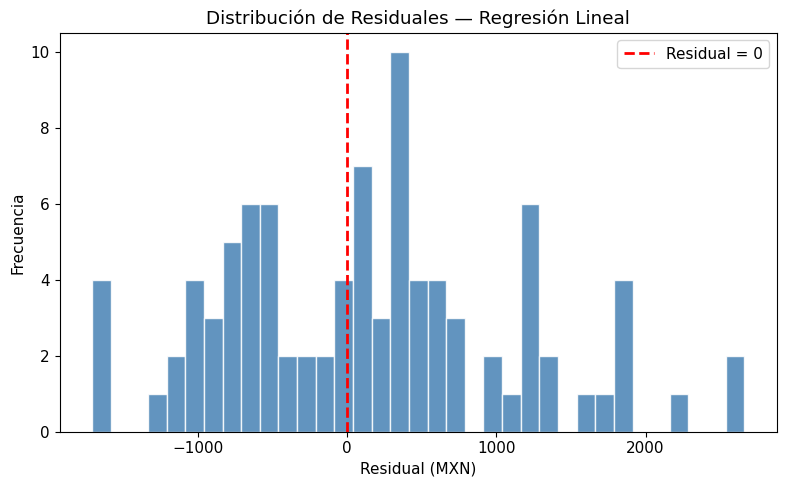

Media de residuales : $140.54 MXN
Desv. estándar      : $969.92 MXN


In [234]:
# Histograma de residuales
residuals_LinearRegression = y_test - y_pred_LinearRegression

plt.figure(figsize=(8, 5))
plt.hist(residuals_LinearRegression, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=2, label='Residual = 0')
plt.xlabel('Residual (MXN)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuales — Regresión Lineal')
plt.legend()
plt.tight_layout()
plt.show()

print(f'Media de residuales : ${residuals_LinearRegression.mean():,.2f} MXN')
print(f'Desv. estándar      : ${residuals_LinearRegression.std():,.2f} MXN')

**Interpretación:**
Una distribución de residuales centrada en cero y con forma aproximadamente normal indica
que el modelo no tiene sesgo sistemático. La desviación estándar de los residuales refleja
el error típico del modelo en pesos.

In [235]:
# Exportar el modelo entrenado con joblib
joblib.dump(lr_model, 'modelo_regresion_lineal.pkl')
joblib.dump(escalador,           'escalador.pkl')
print('Modelo exportado: modelo_regresion_lineal.pkl')
print('Escalador exportado: escalador.pkl')

Modelo exportado: modelo_regresion_lineal.pkl
Escalador exportado: escalador.pkl


---
## Fase 6 — Modelado: Red Neuronal (MLPRegressor)

Se aplica el **Perceptrón Multicapa** (`MLPRegressor`) de scikit-learn como modelo alternativo.
Se usa la misma validación cruzada de 7 pliegues para comparar los resultados con Regresión Lineal.

**Arquitectura:** dos capas ocultas de 100 y 50 neuronas; función de activación: ReLU;
optimizador: Adam; máximo 500 épocas.

In [236]:
# Validación cruzada Red Neuronal — 7 corridas
model_MLP = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500,
                          activation='relu', solver='adam', random_state=42)

cv_MLP = cross_validate(model_MLP, X_full_scaled, y, cv=7,
                                scoring=['r2', 'neg_mean_absolute_error'])

tabla_cv_MLP = pd.DataFrame({
    'R²' : cv_MLP['test_r2'].round(4),
    'MAE': (-cv_MLP['test_neg_mean_absolute_error']).round(2)
})
fila_promedio_red = pd.DataFrame({
    'R²' : [round(cv_MLP['test_r2'].mean(), 4)],
    'MAE': [round((-cv_MLP['test_neg_mean_absolute_error']).mean(), 2)]
})
tabla_cv_MLP = pd.concat([tabla_cv_MLP, fila_promedio_red], ignore_index=True)
tabla_cv_MLP.index = list(range(1, 8)) + ['Promedio']

print('=== Red Neuronal (MLP) — Validación Cruzada (7 corridas) ===')
print(tabla_cv_MLP.to_string())

=== Red Neuronal (MLP) — Validación Cruzada (7 corridas) ===
              R²      MAE
1         0.4564  1078.09
2         0.6103   894.27
3         0.7147   746.01
4         0.7892   817.25
5         0.6916   983.32
6         0.4581  1324.28
7         0.4628   687.20
Promedio  0.5976   932.92


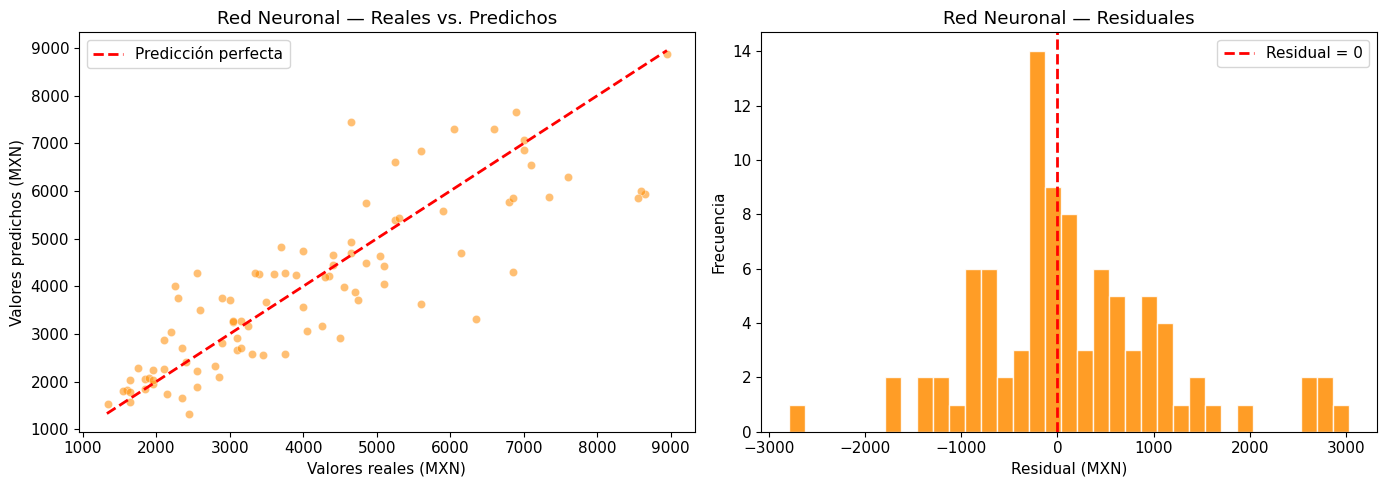

Media de residuales : $138.69 MXN
Desv. estándar      : $1,012.74 MXN


In [237]:
# Corrida única Red Neuronal: entrenamiento + visualización
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=5000,
                                activation='relu', solver='adam', random_state=42)
mlp_model.fit(X_train_sc, y_train)
y_pred_MLP = mlp_model.predict(X_test_sc)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

ejes[0].scatter(y_test, y_pred_MLP, alpha=0.55, color='darkorange',
                edgecolors='white', linewidth=0.4, s=35)
minv = min(y_test.min(), y_pred_MLP.min())
maxv = max(y_test.max(), y_pred_MLP.max())
ejes[0].plot([minv, maxv], [minv, maxv], 'r--', linewidth=2, label='Predicción perfecta')
ejes[0].set_xlabel('Valores reales (MXN)')
ejes[0].set_ylabel('Valores predichos (MXN)')
ejes[0].set_title('Red Neuronal — Reales vs. Predichos')
ejes[0].legend()

residuals_MLP = y_test - y_pred_MLP
ejes[1].hist(residuals_MLP, bins=35, color='darkorange', edgecolor='white', alpha=0.85)
ejes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Residual = 0')
ejes[1].set_xlabel('Residual (MXN)')
ejes[1].set_ylabel('Frecuencia')
ejes[1].set_title('Red Neuronal — Residuales')
ejes[1].legend()

plt.tight_layout()
plt.show()

print(f'Media de residuales : ${residuals_MLP.mean():,.2f} MXN')
print(f'Desv. estándar      : ${residuals_MLP.std():,.2f} MXN')

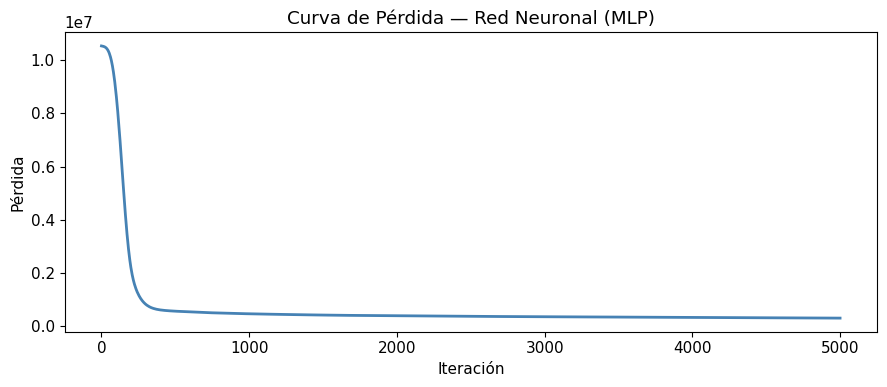

Iteraciones entrenadas: 5000
Pérdida final         : 281986.5452


In [238]:
# Curva de pérdida de la Red Neuronal
plt.figure(figsize=(9, 4))
plt.plot(mlp_model.loss_curve_, color='steelblue', linewidth=2)
plt.xlabel('Iteración')
plt.ylabel('Pérdida')
plt.title('Curva de Pérdida — Red Neuronal (MLP)')
plt.tight_layout()
plt.show()

print(f'Iteraciones entrenadas: {mlp_model.n_iter_}')
print(f'Pérdida final         : {mlp_model.loss_:.4f}')

**Interpretación:**
La curva de pérdida muestra cómo el error del modelo disminuye a lo largo de las épocas de entrenamiento.
Una curva que converge suavemente indica un entrenamiento estable.
Si la curva no converge o presenta oscilaciones, podría indicar un problema con la tasa de aprendizaje
o la arquitectura de la red.

---
## Fase 7 — Evaluación y Comparación de Modelos

Se comparan los dos modelos entrenados usando los promedios de la validación cruzada de 7 pliegues.

In [239]:
# Tabla comparativa final
from sklearn.metrics import r2_score, mean_absolute_error

r2_lineal_prueba  = r2_score(y_test, y_pred_LinearRegression)
mae_lineal_prueba = mean_absolute_error(y_test, y_pred_LinearRegression)
r2_red_prueba     = r2_score(y_test, y_pred_MLP)
mae_red_prueba    = mean_absolute_error(y_test, y_pred_MLP)

r2_lineal_cv  = cv_LinearRegression['test_r2'].mean()
mae_lineal_cv = (-cv_LinearRegression['test_neg_mean_absolute_error']).mean()
r2_red_cv     = cv_MLP['test_r2'].mean()
mae_red_cv    = (-cv_MLP['test_neg_mean_absolute_error']).mean()

tabla_comparacion = pd.DataFrame({
    'Modelo'         : ['Regresión Lineal', 'Red Neuronal (MLP)'],
    'R2 (test)'      : [round(r2_lineal_prueba,  4), round(r2_red_prueba,  4)],
    'MAE (test)'     : [round(mae_lineal_prueba,  2), round(mae_red_prueba,  2)],
    'R2 promedio CV' : [round(r2_lineal_cv,  4), round(r2_red_cv,  4)],
    'MAE promedio CV': [round(mae_lineal_cv, 2), round(mae_red_cv, 2)]
}).set_index('Modelo')

print(tabla_comparacion.to_string())

                    R2 (test)  MAE (test)  R2 promedio CV  MAE promedio CV
Modelo                                                                    
Regresión Lineal       0.7353      781.90          0.6882           829.86
Red Neuronal (MLP)     0.7121      745.14          0.5976           932.92


---
## Conclusiones

- Se construyó un sistema de predicción de precios para obras de arte de la galería NU★B Studio
  utilizando datos almacenados en una base de datos PostgreSQL (Neon Cloud).
- A través de tres métodos de selección de características (correlación, RFE e importancia por
  Random Forest), se realizó una **búsqueda exhaustiva de N=5 a N=30** para encontrar el número
  óptimo de características: **N=13** maximiza el R² en validación cruzada de 7 pliegues.
- Las 13 características seleccionadas por consenso (≥ 2 métodos) fueron:
  `alto_cm`, `ancho_cm`, `anio_creacion`, `categoria_Cerámica`, `categoria_Escultura`,
  `categoria_Fotografía`, `categoria_Ilustración`, `categoria_Pintura`, `con_certificado`,
  `disponible_envio`, `es_original`, `material_Papel fotográfico`, `material_Tela`.
- Se entrenaron y evaluaron dos modelos con validación cruzada de 7 pliegues:
  - **Regresión Lineal** — modelo base, interpretable y eficiente
  - **MLPRegressor** — red neuronal multicapa, captura relaciones no lineales
- La **Regresión Lineal** obtuvo el mejor desempeño general:
  - R² en prueba: **0.7353** vs MLP: 0.7121
  - MAE en prueba: **$781.90 MXN** vs MLP: $745.14 MXN
  - R² CV promedio: **0.6882** vs MLP: 0.5976
  - MAE CV promedio: **$829.86 MXN** vs MLP: $932.92 MXN
- La Red Neuronal (MLP) presenta una brecha considerable entre su R² en prueba (0.71) y en CV
  (0.60), señal de sobreajuste. La Regresión Lineal tiene una brecha mucho menor (0.73 vs 0.69),
  lo que indica mejor capacidad de generalización a datos nuevos.
- El modelo exportado con `joblib` puede integrarse a la plataforma NU★B Studio
  para sugerir precios a nuevos artistas al publicar sus obras.